In [1]:
import sys
print(f"Python: {sys.executable}")
print("Installing packages...")

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install numpy  pandas matplotlib seaborn scikit-learn tqdm pillow jupyter

print("\nAll packages installed successfully!")

Python: c:\Users\Professional\.conda\envs\kursach_env\python.exe
Installing packages...
Looking in indexes: https://download.pytorch.org/whl/cpu

All packages installed successfully!


In [ ]:
import json
import os

db_path = os.path.join("data", "nutrition_db.json")
with open(db_path, "r") as f:
    nutrition_db = json.load(f)

dish = "borsh"
print(f"{dish}: {nutrition_db[dish]['calories']} ккал, {nutrition_db[dish]['protein']} г белка")

borsh: 50 ккал, 1.5 г белка


In [3]:
import sys
!{sys.executable} -m pip uninstall numpy pandas -y
!{sys.executable} -m pip install numpy==1.23.5
!{sys.executable} -m pip install pandas

print("completed")

Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3


You can safely remove it manually.


  Using cached numpy-1.23.5-cp39-cp39-win_amd64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp39-cp39-win_amd64.whl (14.7 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seaborn 0.12.2 requires pandas>=0.25, which is not installed.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.23.5 which is incompatible.


  Using cached pandas-2.3.3-cp39-cp39-win_amd64.whl.metadata (19 kB)
Using cached pandas-2.3.3-cp39-cp39-win_amd64.whl (11.4 MB)
completed


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
from torchvision import transforms, datasets

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import random


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

#gpu test
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 2060
Memory: 6.4 GB


In [4]:
import shutil
import os

src_dir = "data"
dst_dir = "data_clean"

for class_name in os.listdir(src_dir):
    src_class = os.path.join(src_dir, class_name)
    if not os.path.isdir(src_class) or class_name.startswith("."):
        continue
    dst_class = os.path.join(dst_dir, class_name)
    os.makedirs(dst_class, exist_ok=True)
    for f in os.listdir(src_class):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            shutil.copy(os.path.join(src_class, f), os.path.join(dst_class, f))

In [5]:
#transforms
transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])
data_dir='data_clean'
def is_image_file(path):
    valid_ext = (".jpg", ".jpeg", ".png")
    if ".ipynb_checkpoints" in path:
        return False
    return path.lower().endswith(valid_ext)

dataset=datasets.ImageFolder(root=data_dir, transform=transform, is_valid_file=is_image_file)
class_names=dataset.classes
num_classes=len(class_names)
print(f"Done {num_classes} classes")

Done 15 classes


In [6]:
all_images = [path for path, _ in dataset.imgs]
all_labels = [label for _, label in dataset.imgs]
train_imgs, temp_imgs, train_labels, temp_labels=train_test_split(all_images, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
val_imgs, test_imgs, val_labels, test_labels=train_test_split(temp_imgs, temp_labels, test_size=1/3, stratify=temp_labels, random_state=42)
print(f"Train: {len(train_imgs)}, val: {len(val_imgs)}, test: {len(test_imgs)}")

Train: 1062, val: 304, test: 152


In [7]:
class CustomImageDataset():
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths=image_paths
        self.labels=labels
        self.transform=transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path=self.image_paths[idx]
        label=self.labels[idx]
        image=Image.open(img_path).convert('RGB')
        if self.transform:
            image=self.transform(image)

        return image, label

batch_size=16
train_dataset=CustomImageDataset(train_imgs, train_labels, transform=transform)
val_dataset=CustomImageDataset(val_imgs, val_labels, transform=transform)
test_dataset=CustomImageDataset(test_imgs, test_labels, transform=transform)

train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        

In [8]:
#model resnet18
from torchvision.models import resnet18, ResNet18_Weights

model=models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc=nn.Linear(model.fc.in_features, num_classes)
model=model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=1e-4)


In [9]:
def train_one_epo(model, loader):
    model.train()
    total_loss=0
    correct=0
    for images, labels in loader:
        images, labels=images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits=model(images)
        loss=criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        preds=torch.argmax(logits, dim=1)
        correct+=(preds==labels).sum().item()
    accuracy=correct/len(loader.dataset)
    return total_loss, accuracy

In [10]:
def validate(model, loader):
    model.eval()
    total_loss=0
    correct=0
    with torch.no_grad():
        for images, labels in loader:
            images, labels=images.to(device), labels.to(device)
            logits=model(images)
            loss=criterion(logits, labels)
            total_loss+=loss.item()
            preds=torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
    accuracy=correct/len(loader.dataset)
    return total_loss, accuracy

c:\Users\Professional\.conda\envs\kursach_env\lib\site-packages\PIL\Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10
Train loss: 77.3006, Train acc: 0.7109
Val   loss: 5.9970, Val acc: 0.9375
Epoch 2/10
Train loss: 14.7966, Train acc: 0.9661
Val   loss: 3.9614, Val acc: 0.9441
Epoch 3/10
Train loss: 7.9979, Train acc: 0.9793
Val   loss: 4.4715, Val acc: 0.9507
Epoch 4/10
Train loss: 4.6465, Train acc: 0.9878
Val   loss: 3.4258, Val acc: 0.9539
Epoch 5/10
Train loss: 3.8541, Train acc: 0.9906
Val   loss: 3.7133, Val acc: 0.9408
Epoch 6/10
Train loss: 2.5422, Train acc: 0.9944
Val   loss: 3.3377, Val acc: 0.9539
Epoch 7/10
Train loss: 1.8607, Train acc: 0.9981
Val   loss: 2.9441, Val acc: 0.9441
Epoch 8/10
Train loss: 1.5556, Train acc: 1.0000
Val   loss: 2.7454, Val acc: 0.9671
Epoch 9/10
Train loss: 2.2177, Train acc: 0.9953
Val   loss: 2.8092, Val acc: 0.9638
Epoch 10/10
Train loss: 2.8926, Train acc: 0.9944
Val   loss: 3.2398, Val acc: 0.9441


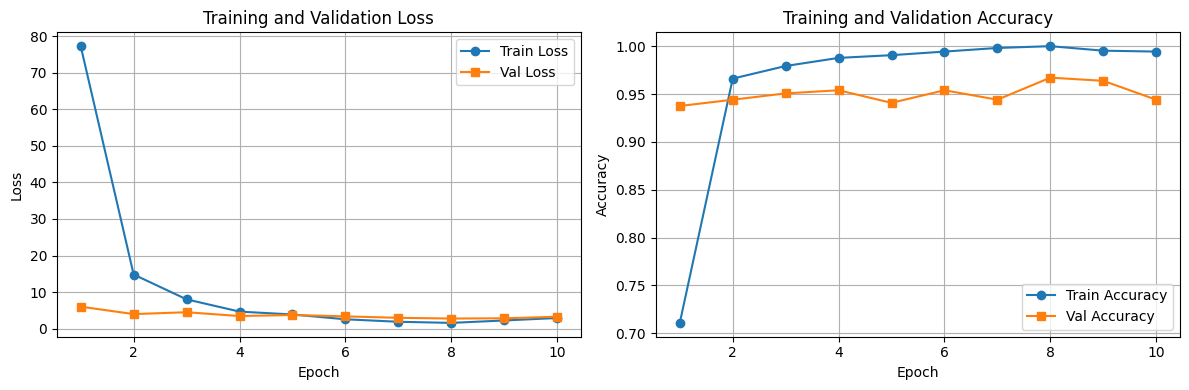

In [11]:
num_epochs=10
train_losses=[]
train_accs=[]
val_losses=[]
val_accs= []

for epoch in range(num_epochs):
    train_loss, train_acc=train_one_epo(model, train_loader)
    val_loss, val_acc=validate(model, val_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")
    print(f"Val   loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
#loss
ax1.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
ax1.plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

#accuracy
ax2.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy', marker='o')
ax2.plot(range(1, num_epochs+1), val_accs, label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

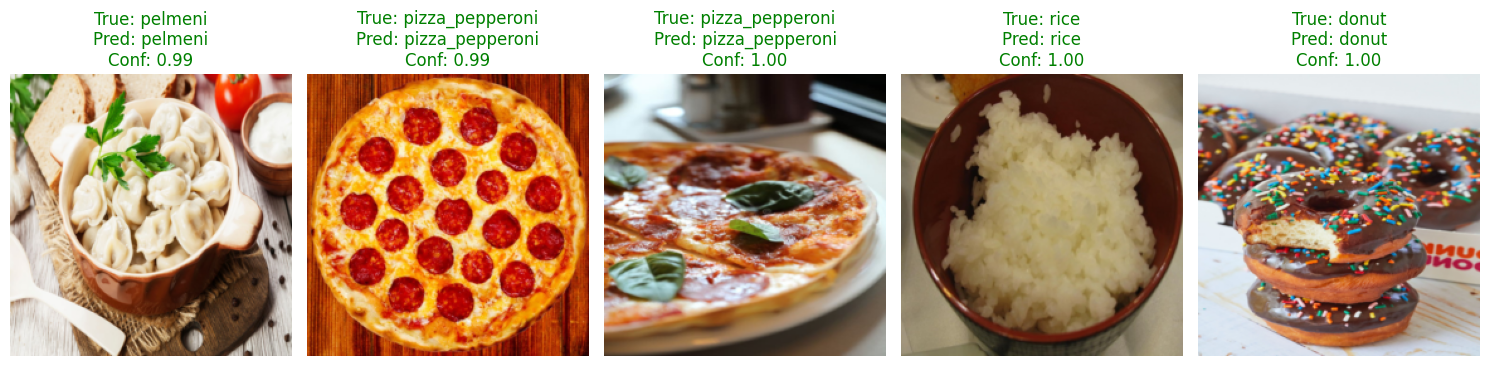

In [12]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img_tensor * std + mean

def test_random_samples(model, dataset, class_names, device, n=5):
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    plt.figure(figsize=(15, 10))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(image_input)
            probs = torch.softmax(logits, dim=1)

            confidence, pred_class = torch.max(probs, dim=1)

        img_show = denormalize(image).permute(1,2,0).cpu().numpy()
        img_show = img_show.clip(0, 1)

        true_name = class_names[label]
        pred_name = class_names[pred_class.item()]
        conf = confidence.item()

        plt.subplot(1, n, i+1)
        plt.imshow(img_show)
        plt.axis("off")

        color = "green" if pred_name == true_name else "red"

        plt.title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}",
            color=color
        )

    plt.tight_layout()
    plt.show()

test_random_samples(model, test_dataset, class_names, device, n=5)

In [13]:
torch.save(model.state_dict(), "model_1.pth")

print("model_1 saved")

model_1 saved


In [15]:
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved")

Class names saved
